# Person specfic analysis (i.e, scores)

In [8]:
import pandas as pd

input_folder_base = "/Users/paulh/runs-svn/matsim-berlin/autofrei/1pct-v6.4/berlin-autofrei-v6.4-baseCaseCtdExtended"
input_folder_policy = "/Users/paulh/runs-svn/matsim-berlin/autofrei/1pct-v6.4/berlin-autofrei-v6.4-policy"


def read_persons(input_folder):
    # person column is a string
    df = pd.read_csv(input_folder + "/berlin-v6.4.output_persons.csv.zst", sep=";", low_memory=False,
                     dtype={"person": "string"}, )
    df["monetarized_score"] = df["executed_score"] / df["marginalUtilityOfMoney"]
    return df


base_persons = read_persons(input_folder_base)
policy_persons = read_persons(input_folder_policy)
base_persons

,person,executed_score,first_act_x,first_act_y,first_act_type,RegioStaR7,age,ars,bikeAvail,carAvail,...,subpopulation,ref_id,ref_modes,ref_weight,lor,zone,purpose,tourStartArea,vehicleTypes,monetarized_score
0,bb_00005f6f,99.809194,766625.23,5872598.05,home_86400,7.0,40.0,1.206858e+11,always,always,...,person,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,68.712185
1,bb_000820ed,139.682723,820356.82,5799630.27,home_86400,4.0,63.0,1.206102e+11,never,always,...,person,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,126.244889
2,bb_000905ff,152.989806,784159.24,5838621.55,home_86400,3.0,13.0,1.206501e+11,always,never,...,person,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,88.493950
3,bb_000f0451,158.485441,807901.68,5844018.06,home_86400,3.0,47.0,1.206002e+11,always,always,...,person,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,49.110424
4,bb_001079c1,0.000000,772999.38,5836225.31,home_86400,3.0,60.0,1.206301e+11,never,always,...,person,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
52258,goodsTraffic_re_vkz.1941_5_4,16.923088,812259.72,5830204.43,commercial_start,NaN,NaN,NaN,NaN,NaN,...,goodsTraffic,NaN,NaN,NaN,NaN,NaN,5.0,re_vkz.1941,org.matsim.vehicles.PersonVehicleTypes@5a828061,NaN
52259,goodsTraffic_re_vkz.1942_5_17,78.359953,811592.59,5831447.76,commercial_start,NaN,NaN,NaN,NaN,NaN,...,goodsTraffic,NaN,NaN,NaN,NaN,NaN,5.0,re_vkz.1942,org.matsim.vehicles.PersonVehicleTypes@7d596095,NaN
52260,goodsTraffic_re_vkz.1951_4_8,70.183513,812516.20,5829825.07,commercial_start,NaN,NaN,NaN,NaN,NaN,...,goodsTraffic,NaN,NaN,NaN,NaN,NaN,4.0,re_vkz.1951,org.matsim.vehicles.PersonVehicleTypes@16f76f2a,NaN
52261,goodsTraffic_re_vkz.1952_3_1,-2.813844,812367.46,5831015.38,commercial_start,NaN,NaN,NaN,NaN,NaN,...,goodsTraffic,NaN,NaN,NaN,NaN,NaN,3.0,re_vkz.1952,org.matsim.vehicles.PersonVehicleTypes@40808096,NaN


In [21]:
# join bass and policy persons based on "person" column. retain all columns.
joined = base_persons.merge(policy_persons, on="person", suffixes=("_base", "_policy"))
joined = joined[joined["subpopulation_base"] == "person"]
joined

,person,executed_score_base,first_act_x_base,first_act_y_base,first_act_type_base,RegioStaR7_base,age_base,ars_base,bikeAvail_base,carAvail_base,...,subpopulation_policy,ref_id_policy,ref_modes_policy,ref_weight_policy,lor_policy,zone_policy,purpose_policy,tourStartArea_policy,vehicleTypes_policy,monetarized_score_policy
0,bb_00005f6f,99.809194,766625.230000,5.872598e+06,home_86400,7.0,40.0,1.206858e+11,always,always,...,person,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,70.092635
1,bb_000820ed,139.682723,820356.820000,5.799630e+06,home_86400,4.0,63.0,1.206102e+11,never,always,...,person,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,126.309670
2,bb_000905ff,152.989806,784159.240000,5.838622e+06,home_86400,3.0,13.0,1.206501e+11,always,never,...,person,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,88.493950
3,bb_000f0451,158.485441,807901.680000,5.844018e+06,home_86400,3.0,47.0,1.206002e+11,always,always,...,person,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,49.110424
4,bb_001079c1,0.000000,772999.380000,5.836225e+06,home_86400,3.0,60.0,1.206301e+11,never,always,...,person,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48963,berlin_fff8f001,122.340066,807065.141931,5.817084e+06,home_86400,1.0,11.0,1.100000e+11,always,never,...,person,NaN,NaN,NaN,8041040.0,8.0,NaN,NaN,NaN,154.167063
48964,berlin_fffa1c81,121.510197,798450.818532,5.829558e+06,home_86400,1.0,57.0,1.100000e+11,never,always,...,person,NaN,NaN,NaN,1011402.0,1.0,NaN,NaN,NaN,138.060190
48965,berlin_fffa2ce6,148.686783,786942.622696,5.830594e+06,home_86400,1.0,19.0,1.100000e+11,always,always,...,person,NaN,NaN,NaN,5030730.0,5.0,NaN,NaN,NaN,19.197534
48966,berlin_fffafb83,156.750857,805117.857177,5.840357e+06,home_86400,1.0,86.0,1.100000e+11,never,always,...,person,NaN,NaN,NaN,3010102.0,3.0,NaN,NaN,NaN,267.151075


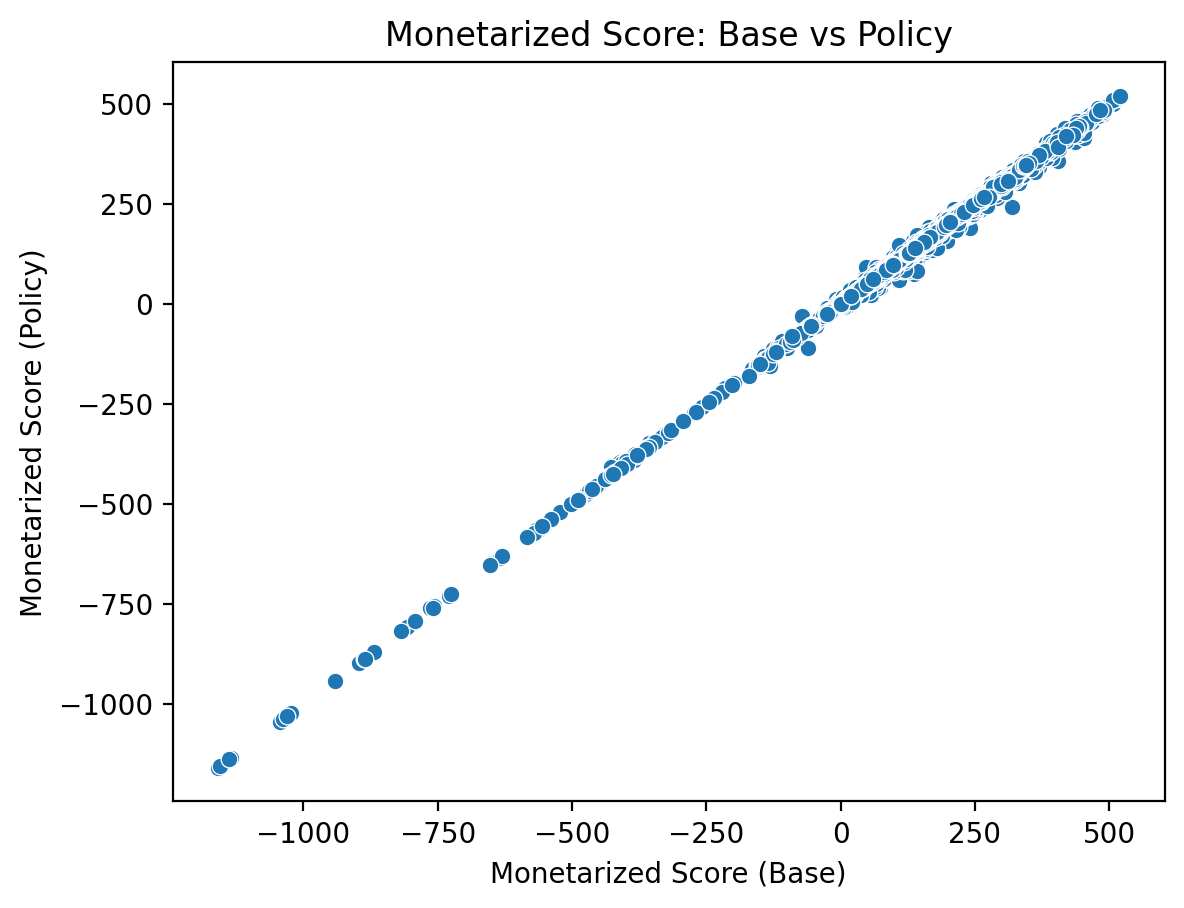

In [22]:
import seaborn as sns
import matplotlib.pyplot as plt

%config InlineBackend.figure_format = 'retina'


sns.scatterplot(data=joined, x="monetarized_score_base", y="monetarized_score_policy")
plt.xlabel("Monetarized Score (Base)")
plt.ylabel("Monetarized Score (Policy)")
plt.title("Monetarized Score: Base vs Policy")
plt.show()

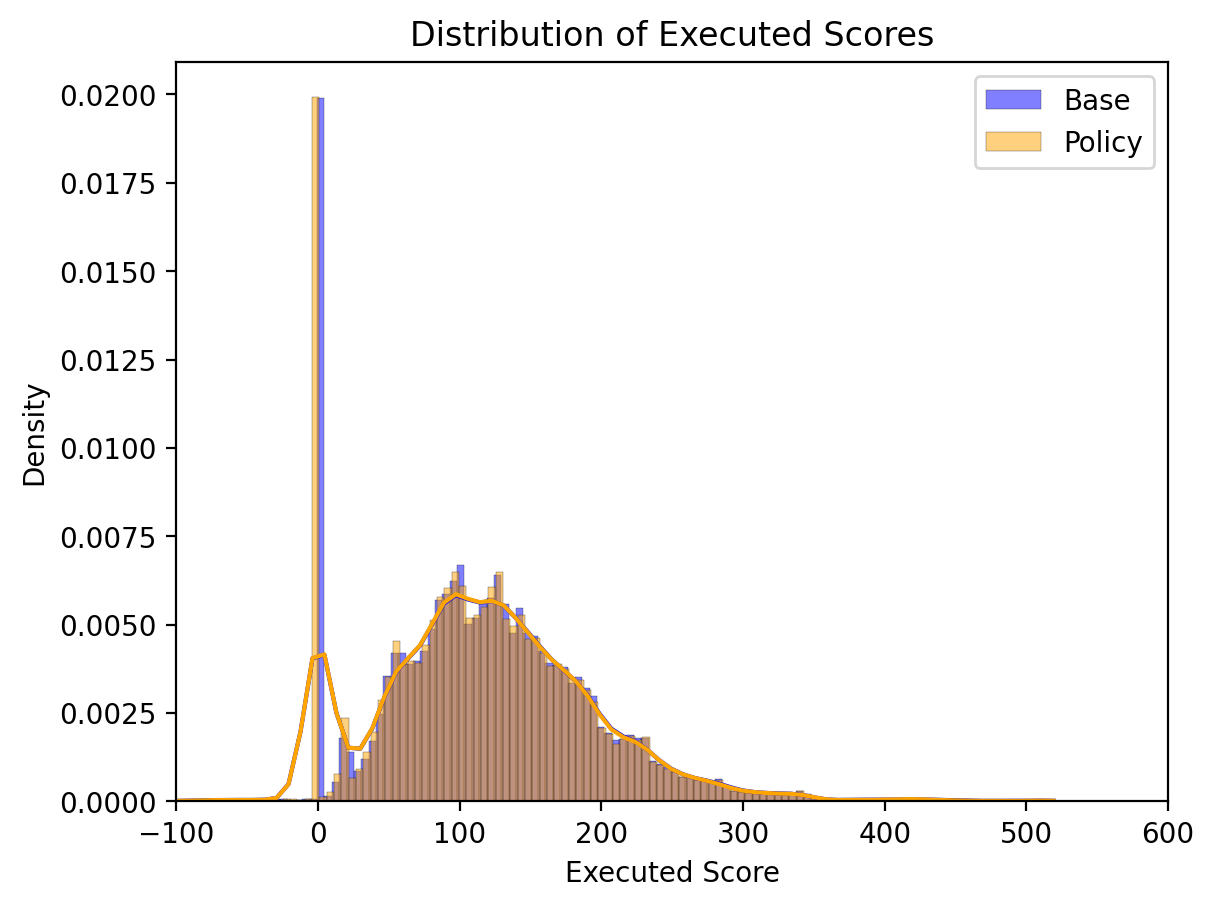

In [24]:
# plot the distribution of executed_score_base and executed_score_policy as histograms
sns.histplot(joined["monetarized_score_base"], color="blue", label="Base", kde=True, stat="density")
sns.histplot(joined["monetarized_score_policy"], color="orange", label="Policy", kde=True, stat="density")

# restrict x axis to -100 to 200
plt.xlim(-100, 600)
plt.xlabel("Executed Score")
plt.ylabel("Density")
plt.title("Distribution of Executed Scores")
plt.legend()
plt.show()

In [29]:
# plot the diff between monetarized_score_base and monetarized_score_policy as a histogram
joined["monetarized_score_diff"] = joined["monetarized_score_policy"] - joined["monetarized_score_base"]
print(joined["monetarized_score_diff"].describe())


count    48968.000000
mean        -0.239367
std          2.277370
min        -78.211182
25%         -0.000105
50%          0.000000
75%          0.000000
max         45.471643
Name: monetarized_score_diff, dtype: float64


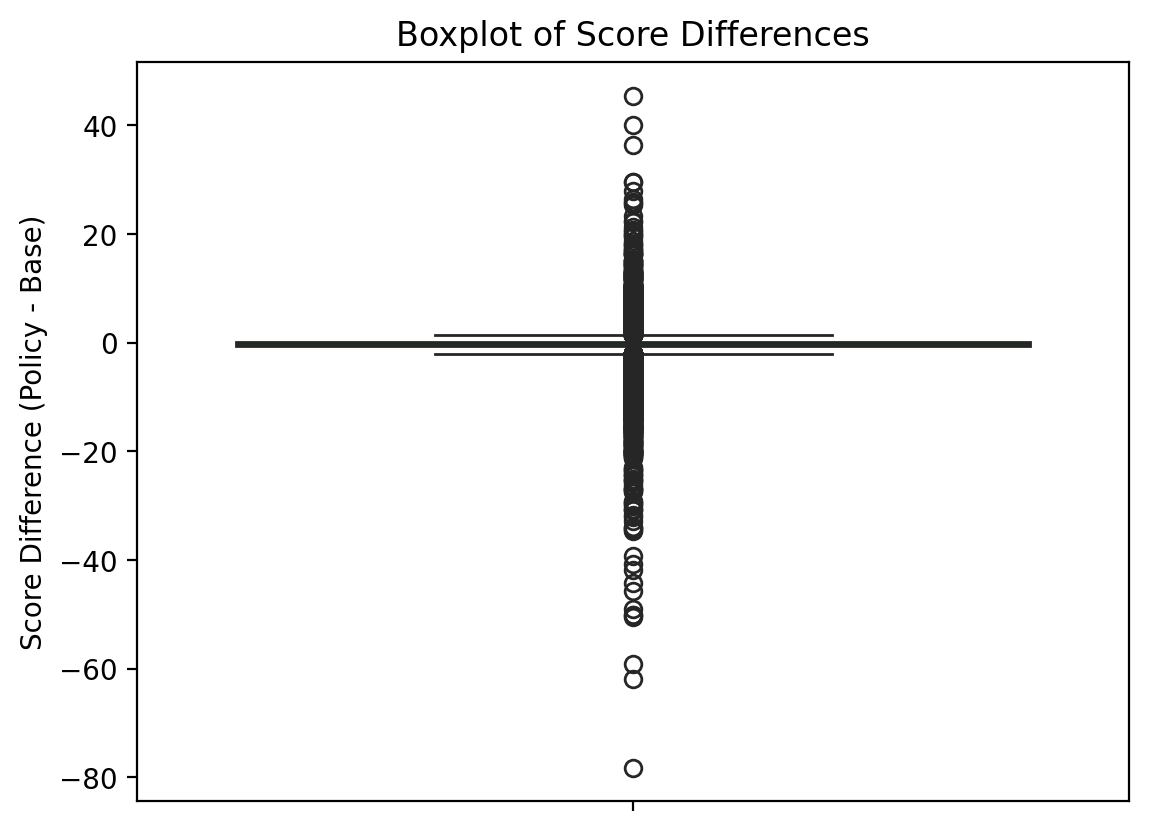

In [43]:
changed_persons = joined.loc[joined["monetarized_score_diff"] != 0.0].copy()

sns.boxplot(data=changed_persons, y="monetarized_score_diff", color="green")
plt.ylabel("Score Difference (Policy - Base)")
plt.title("Boxplot of Score Differences")
plt.show()


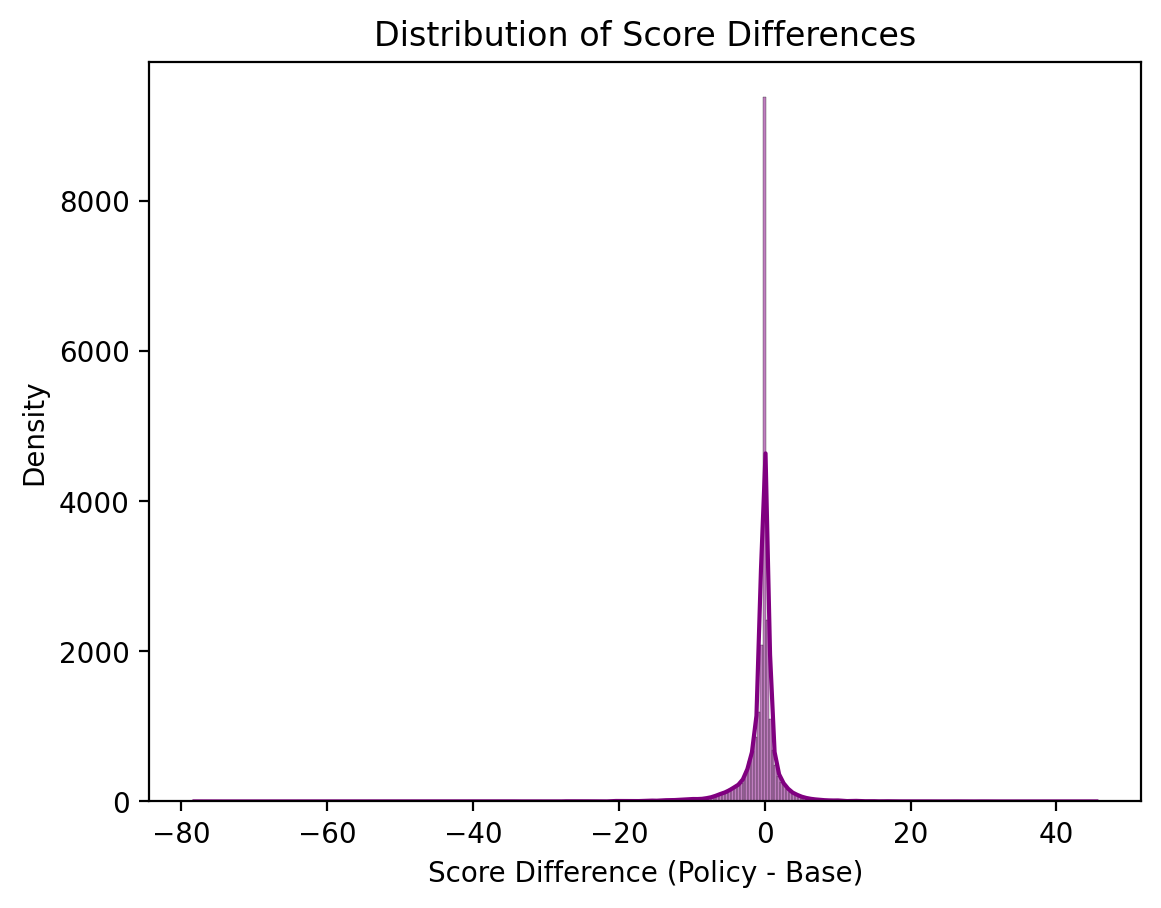

In [46]:
# create a distribution of the score differences
sns.histplot(changed_persons["monetarized_score_diff"], color="purple", kde=True)
plt.xlabel("Score Difference (Policy - Base)")
plt.ylabel("Density")
plt.title("Distribution of Score Differences")
plt.show()

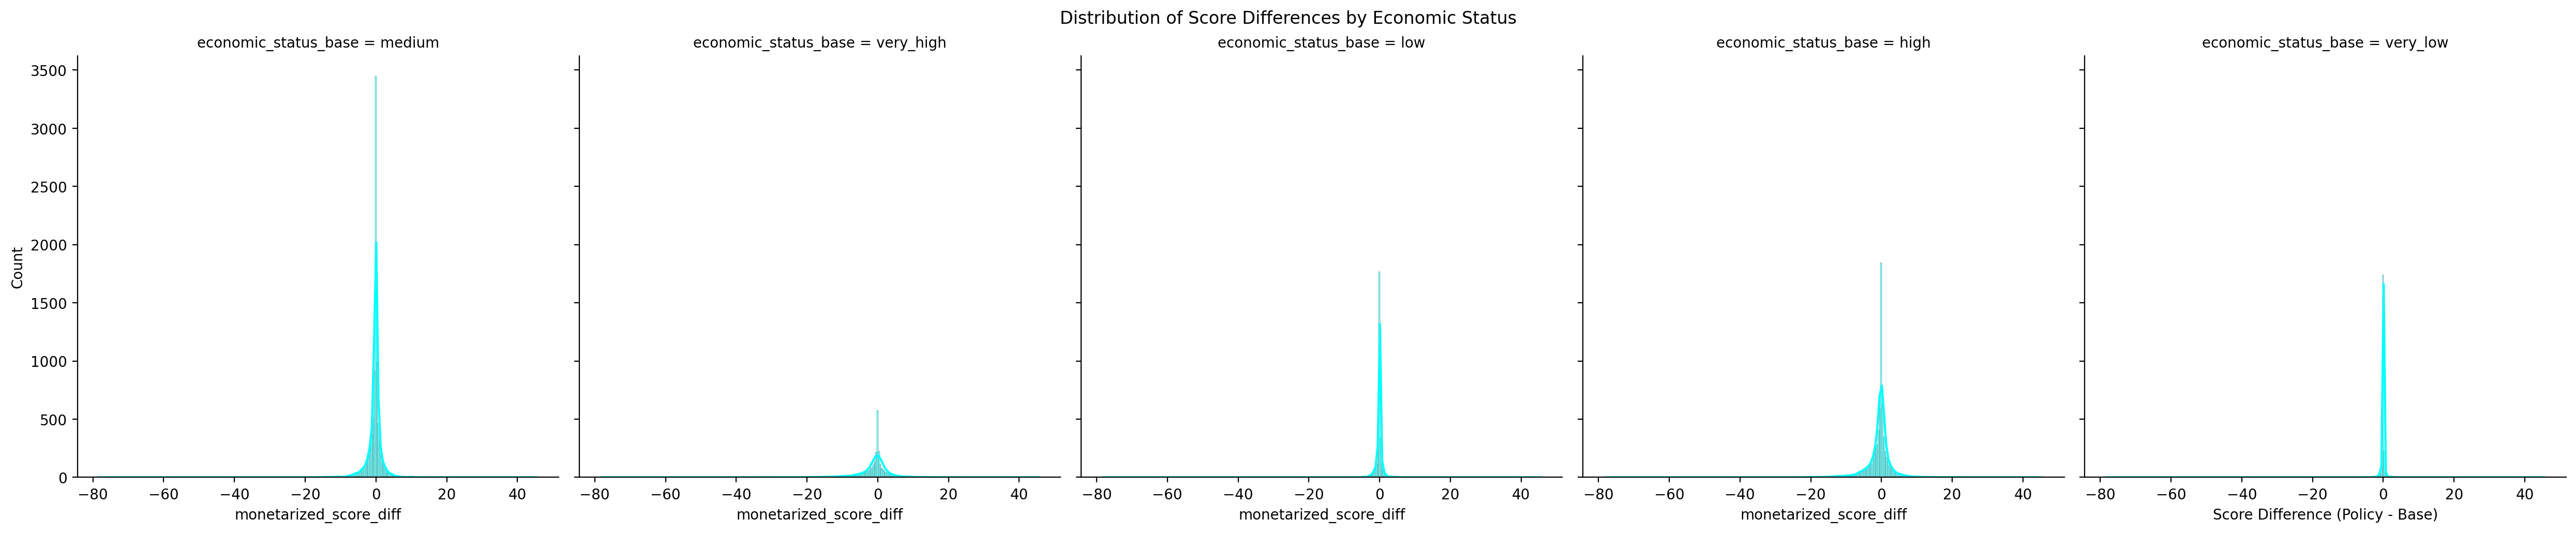

In [47]:
# do a facet plot: for each economic_status plot the distribution of score differences
sns.displot(data=changed_persons, x="monetarized_score_diff", col="economic_status_base", color="cyan", kde=True)
plt.xlabel("Score Difference (Policy - Base)")
plt.ylabel("Density")
plt.suptitle("Distribution of Score Differences by Economic Status", y=1.02)
plt.show()

In [48]:
# for each economic_status describe the score differences
for status in changed_persons["economic_status_base"].unique():
    subset = changed_persons[changed_persons["economic_status_base"] == status]
    print(f"Economic Status: {status}")
    print(subset["monetarized_score_diff"].describe())
    print("\n")


Economic Status: medium
count    9155.000000
mean       -0.323294
std         2.134119
min       -30.052437
25%        -0.615198
50%        -0.001238
75%         0.209838
max        18.096100
Name: monetarized_score_diff, dtype: float64


Economic Status: very_high
count    2740.000000
mean       -1.204768
std         5.843964
min       -78.211182
25%        -2.085528
50%        -0.149003
75%         0.469518
max        45.471643
Name: monetarized_score_diff, dtype: float64


Economic Status: low
count    2.991000e+03
mean    -8.785498e-02
std      9.896878e-01
min     -1.176193e+01
25%     -1.550461e-01
50%     -2.842171e-14
75%      6.645285e-02
max      9.258779e+00
Name: monetarized_score_diff, dtype: float64


Economic Status: high
count    7036.000000
mean       -0.733369
std         3.940740
min       -61.879403
25%        -1.412271
50%        -0.065856
75%         0.348300
max        40.073544
Name: monetarized_score_diff, dtype: float64


Economic Status: very_low
count    2.2

In [52]:
joined.sort_values(by=["monetarized_score_diff"], ascending=False).head(5)

,person,executed_score_base,first_act_x_base,first_act_y_base,first_act_type_base,RegioStaR7_base,age_base,ars_base,bikeAvail_base,carAvail_base,...,ref_modes_policy,ref_weight_policy,lor_policy,zone_policy,purpose_policy,tourStartArea_policy,vehicleTypes_policy,monetarized_score_policy,score_diff,monetarized_score_diff
6554,bb_919e0fda,29.408077,774657.440000,5.815161e+06,home_86400,2.0,26.0,1.205400e+11,always,always,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,91.794947,45.471643,45.471643
6301,bb_8b334e19,-61.107296,826578.230000,5.729020e+06,home_86400,6.0,33.0,1.206201e+11,always,always,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-31.818338,40.073544,40.073544
46850,berlin_f1e43a28,51.480608,784768.614259,5.830028e+06,home_86400,1.0,67.0,1.100000e+11,always,always,...,NaN,NaN,5010313.0,5.0,NaN,NaN,NaN,145.359623,36.351067,36.351067
1884,bb_28e8baf5,30.009668,779946.510000,5.849162e+06,home_86400,4.0,47.0,1.206503e+11,always,always,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,76.901476,29.630553,29.630553
34547,berlin_9d9a55f8,67.422200,800296.772742,5.824219e+06,home_86400,1.0,51.0,1.100000e+11,always,always,...,NaN,NaN,8010116.0,8.0,NaN,NaN,NaN,172.297304,29.532932,29.532932


In [53]:
joined.sort_values(by=["monetarized_score_diff"], ascending=True).head(5)

,person,executed_score_base,first_act_x_base,first_act_y_base,first_act_type_base,RegioStaR7_base,age_base,ars_base,bikeAvail_base,carAvail_base,...,ref_modes_policy,ref_weight_policy,lor_policy,zone_policy,purpose_policy,tourStartArea_policy,vehicleTypes_policy,monetarized_score_policy,score_diff,monetarized_score_diff
35562,berlin_a4b8affa,101.468956,794364.001210,5.828700e+06,home_86400,1.0,59.0,1.100000e+11,never,always,...,NaN,NaN,1022104.0,1.0,NaN,NaN,NaN,241.454558,-78.211182,-78.211182
3166,bb_44fea7a8,64.291402,870978.900000,5.809717e+06,home_86400,5.0,37.0,1.205300e+11,always,always,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,74.255603,-61.879403,-61.879403
27471,berlin_6d8c56bd,80.526448,794202.191183,5.823794e+06,home_86400,1.0,39.0,1.100000e+11,always,always,...,NaN,NaN,4051655.0,4.0,NaN,NaN,NaN,82.255819,-59.144544,-59.144544
3588,bb_4e15f078,91.252537,835501.310000,5.764157e+06,home_86400,6.0,58.0,1.206103e+11,always,always,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,189.962671,-50.389577,-50.389577
27891,berlin_706266df,102.661016,793060.176299,5.825096e+06,home_86400,1.0,21.0,1.100000e+11,always,always,...,NaN,NaN,4051446.0,4.0,NaN,NaN,NaN,58.569196,-50.121529,-50.121529
